https://arxiv.org/pdf/2510.11083

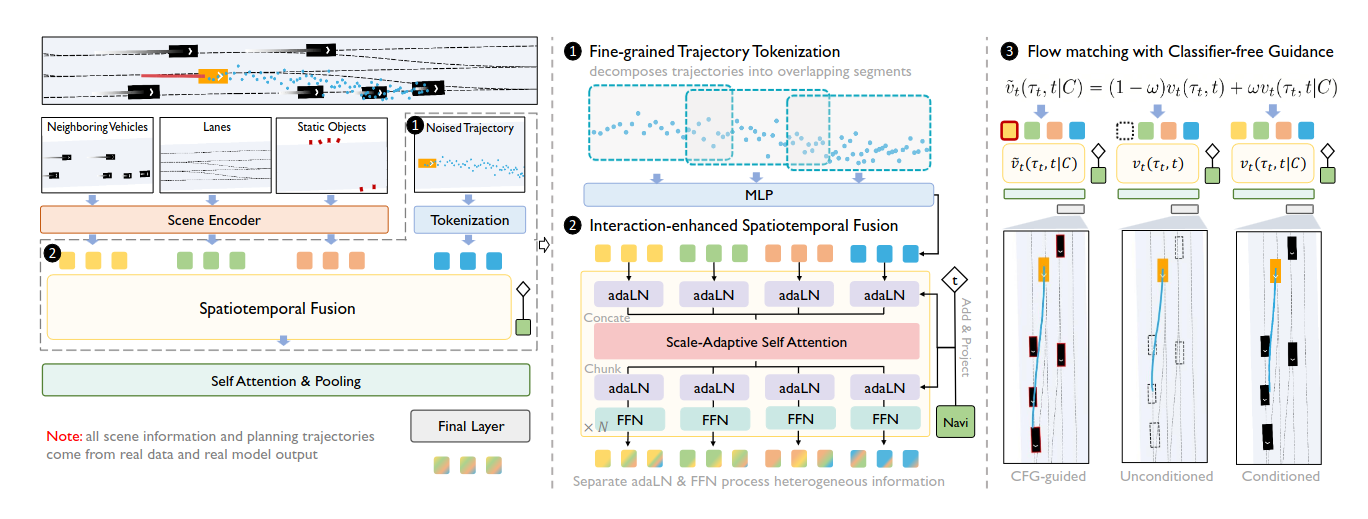

# Flow Planner 论文详解

## 一、论文概况与核心思想

这篇题为 **《Flow Matching-Based Autonomous Driving Planning with Advanced Interactive Behavior Modeling》** 的论文发表于 NeurIPS 2025，作者来自清华大学智能产业研究院（AIR）等机构。其核心思想是：

- 针对自动驾驶规划中**交互行为建模**这一核心挑战，提出 **Flow Planner** 框架。
- 从**数据建模、模型架构、学习范式**三个层面协同创新：
  1. **细粒度轨迹分词**：将完整轨迹分解为重叠片段，降低建模复杂度，同时保持运动学连续性。
  2. **交互增强时空融合**：通过尺度自适应注意力与分离的自适应层归一化（adaLN）和 FFN，高效融合异构场景信息，提升对关键交互对象的感知。
  3. **流匹配 + 分类器自由引导（CFG）**：利用流匹配损失进行多模态行为生成，并在推理时动态调节场景条件强度，增强交互场景理解。
- 在大规模真实数据集 **nuPlan** 和挑战性交互基准 **interPlan** 上，Flow Planner 在学习型规划器中取得最先进的闭环性能，并能有效处理复杂交互场景（如绕过事故车辆、行人横穿等）。

---

## 二、背景与动机

### 2.1 自动驾驶规划的交互挑战

自动驾驶规划的核心难点在于**交通参与者之间的复杂交互**，尤其是在多车、多行人场景中。车辆需要同时：

- 处理即时交互（如让行、超车）；
- 预测关键参与者的未来行为；
- 保持自身轨迹的运动学一致性。

这些要求对模型的**时空融合能力**提出了极高要求。

### 2.2 现有方法的不足

1. **规则方法**：可解释但依赖大量人工设计，泛化性差，难以应对高度动态环境。
2. **学习型方法（行为克隆）**：
   - 早期 CNN/RNN 方法表达能力有限；
   - 现代 Transformer 方法虽提升可扩展性，但**普通 Transformer 堆叠缺乏针对交互建模的专门设计**，冗余信息可能淹没关键交通参与者信息；
   - 交互数据稀缺导致行为克隆偏向非交互行为，闭环评估中易出现安全事故；
   - 辅助损失虽能惩罚不良行为，但需逐例设计，且可能导致过度保守。
3. **强化学习**：可通过试错自主学习交互，但存在奖励工程困难、探索安全性等问题，仍主要停留在仿真层面。
4. **生成式模型（扩散/流匹配）**：
   - 扩散模型（如 Diffusion Planner）联合生成自车和邻近车辆轨迹，但交互对象被限制为固定数量的最近车辆，可能忽略远处但重要的参与者；
   - 且其架构仍缺乏针对异构信息融合的专门设计。

### 2.3 本文动机

现有生成式规划器虽具有表达力，但尚未充分挖掘其在**交互行为建模**上的潜力。Flow Planner 旨在通过以下创新弥补这一空白：

- 更灵活的轨迹表示，避免单一 token 的过度压缩或逐点 token 的误差累积；
- 更高效的时空融合机制，动态聚焦关键交互对象；
- 利用流匹配和 CFG 进一步提升多模态行为生成与场景条件利用效率。

---

## 三、方法详解

### 3.1 问题定义

规划任务被形式化为**条件生成问题**：从源分布 $ p(\tau_0) $（标准高斯噪声）到目标数据分布 $ q(\tau_1 | C) $（给定场景条件 $ C $ 的规划轨迹 $ \tau_1 $）的变换。模型 $ v_\theta $ 学习预测连接样本对的概率路径上的速度场，目标为流匹配损失：

$$
\mathcal{L} = \mathbb{E}_{t \sim U(0,1), p(\tau_0), q(\tau_1|C)} \left\| v_\theta(\tau_t, t|C) - v_t(\tau_t, t) \right\|^2,
$$

其中 $ \tau_t = \alpha_t \tau_1 + \sigma_t \tau_0 $，$ v_t = \dot{\tau}_t = \dot{\alpha}_t \tau_1 + \dot{\sigma}_t \tau_0 $。Flow Planner 采用最优传输路径，使训练更稳定、收敛更快。

### 3.2 模型架构

Flow Planner 是一个基于 Transformer 的生成式规划器，架构如图 1 所示，主要包括：

#### 3.2.1 场景编码器（Scene Encoder）

- **输入**：向量化场景信息。
  - 邻近智能体（车辆、行人、骑行者）：过去 $ T $ 个时间步的状态，包含坐标、速度、尺寸、类型等，表示为 $ F_{\text{neighbor}} \in \mathbb{R}^{T \times H_{\text{neighbor}}} $。
  - 车道：中心线插值为 $ N $ 个均匀分布的点，包含坐标、边界向量、限速、红绿灯状态，表示为 $ F_{\text{lane}} \in \mathbb{R}^{N \times H_{\text{lane}}} $。
  - 静态物体：通过 MLP 编码。
  - 导航信息：与车道类似，用单独的 MLP-Mixer 处理。
- **编码器**：对邻居和车道分别使用 **MLP-Mixer** 提取信息密集表示，避免复杂设计，同时保留场景信息。

#### 3.2.2 细粒度轨迹分词（Fine-grained Trajectory Tokenization）

这是本文的关键创新之一。传统方法要么用**单一 token** 表示整条轨迹（过度压缩，融合效率低），要么用**逐时间步 token**（误差累积严重）。Flow Planner 采用**重叠分段**的折中方案：

- 将噪声轨迹 $ \tau_t = (x_1, x_2, \dots, x_L) $ 分为 $ K $ 个片段，每个片段包含 $ L_{\text{seg}} $ 个点，相邻片段重叠长度为 $ L_{\text{overlap}} $。
- 每个片段通过共享 MLP 转换为一个轨迹 token：
  $$
  F^k_{\text{ego}} = \text{MLP}( (x_{l_k}, x_{l_k+1}, \dots, x_{r_k}) ), \quad k = 1, \dots, K
  $$
  其中 $ l_k, r_k $ 为片段起止索引。
- 对 token 施加正弦位置编码以注入时间信息，然后沿序列维度拼接得到自车特征 $ F_{\text{ego}} = \text{Concat}(F^1_{\text{ego}}, \dots, F^K_{\text{ego}}) $。
- **重叠设计**保证了最终拼接轨迹的平滑性和运动学一致性（训练时通过一致性损失强化，推理时重叠部分取平均）。

#### 3.2.3 交互增强时空融合（Interaction-enhanced Spatiotemporal Fusion）

该模块旨在高效融合异构场景 token 和轨迹 token，并动态聚焦关键交互对象。包含以下设计：

1. **统一表示空间**：
   - 对车道、邻居、自车轨迹 token 分别应用**分离的自适应 LayerNorm（adaLN）**，将时间步条件和导航信息注入，并将异构特征投影到共享潜在空间。
   - 然后沿序列维度拼接：
     $$
     F_{\text{global}} = \text{Concat}( \text{adaLN}(F_{\text{lane}}), \text{adaLN}(F_{\text{neighbor}}), \text{adaLN}(F_{\text{ego}}) )
     $$

2. **尺度自适应自注意力（Scale-Adaptive Self-Attention）**：
   - 观察到交互强度与空间距离强相关，远处物体可能引入噪声。
   - 受文生图领域尺度自适应注意力启发，在注意力分数中引入**空间距离惩罚**：
     $$
     F_{\text{global}} = \text{Softmax}\left( \frac{F_{\text{global}} W^Q (F_{\text{global}} W^K)^T}{\sqrt{d}} - \lambda \cdot D \right) F_{\text{global}} W^V
     $$
     其中 $ D $ 是 token 之间的欧氏距离矩阵，$ \lambda $ 是由 token 线性投影生成的可学习感受野缩放因子。
   - 直觉：距离过远的 token 注意力分数被降低，使模型将计算资源集中于邻近关键参与者。

3. **分离的 adaLN 和 FFN**：
   - 全局融合后，将 token 按模态拆分回 $ F_{\text{lane}}, F_{\text{neighbor}}, F_{\text{ego}} $。
   - 每种模态分别经过独立的 adaLN 和 FFN 投影，进一步缓解异构模态差异。
   - 上述块堆叠 $ N $ 次，最后通过标准自注意力聚合，对自车 token 池化后经最终层输出规划轨迹。

### 3.3 流匹配与分类器自由引导

#### 3.3.1 训练目标

- 采用**流匹配损失**，但使用重参数化技巧直接预测干净轨迹 $ \tau_1 $（等价于速度预测）。
- 额外引入**一致性损失** $ \mathcal{L}_{\text{consist}} $ 约束相邻片段重叠区域的预测一致性：
  $$
  \mathcal{L}_{\text{consist}} = \frac{1}{K-1} \sum_{k=1}^{K-1} \left\| \hat{\tau}^{k:k+1} - \hat{\tau}^{k+1:k} \right\|^2
  $$
  最终损失：$ \mathcal{L} = \mathcal{L}_{\text{flow}} + \alpha \cdot \mathcal{L}_{\text{consist}} $。

#### 3.3.2 分类器自由引导（CFG）

- 训练时使用 **Bernoulli 掩码**随机丢弃条件信息（特别是邻近车辆信息），使单一模型同时学习条件分布 $ q(\tau_1|C) $ 和无条件分布 $ q(\tau_1) $。
- 推理时通过引导速度场：
  $$
  \tilde{v}_t(\tau_t, t|C) = (1-\omega) v_t(\tau_t, t) + \omega v_t(\tau_t, t|C)
  $$
  其中 $ \omega > 1 $ 控制条件信号强度。
- **效果**：无条件模型忽略邻近车辆，条件模型可能对最近车辆过度反应（过于保守），而 CFG 引导的模型能生成合理响应，平衡安全与效率。如图 1 所示。
- 实际中，仅掩码邻近车辆信息，因为其对交互行为最关键。

### 3.4 实现细节

- **坐标变换**：场景转换到自车中心的前-左-上（FLU）坐标系。
- **归一化**：使用训练数据统计量对输入和真值轨迹进行标准化。
- **数据增强**：对当前帧自车状态随机扰动，使用五次多项式插值生成新真值轨迹，提高鲁棒性。
- **推理**：使用二阶中点法求解流 ODE；重叠区域预测值取平均。

---

## 四、实验与结果

### 4.1 实验设置

- **数据集**：
  - **nuPlan**：大规模真实驾驶数据，覆盖 75 种场景类型。训练使用 1M 分割。
  - **interPlan**：专门设计的挑战性交互基准，包含 335 个高交互场景（如绕行事故车辆、高密度交通、行人横穿等），用于评估交互建模能力。
- **评估协议**：闭环测试，使用 LQR 控制器。在 nuPlan 的 Val14、Test14-hard、Test14 三个子集上分别测试非反应式（NR）和反应式（R）模式。
- **基线**：IDM（规则）、PDM 系列（规则/混合）、PLUTO、GameFormer、PlanTF、Diffusion Planner（学习型）。

### 4.2 主要结果

#### nuPlan 基准（表 1）

- **Flow Planner（纯学习，无后处理）**：
  - Val14：**90.43**（NR）/ **83.31**（R），首次在学习型方法中**无任何先验知识**突破 90 分大关（此前只有 Diffusion Planner 89.87 接近）。
  - Test14-hard：76.47 / 70.42，略优于 Diffusion Planner。
  - Test14：89.88 / 82.93，与 Diffusion Planner 持平或略优。
- **Flow Planner w/ refine**：与规则/混合方法竞争，在多个指标上达到或超越人类水平。

#### 场景细分（表 2）

在交互频繁的场景（如无保护左转、红绿灯路口、等待行人）中，Flow Planner 显著优于 PLUTO 和 Diffusion Planner，证明其在交互建模上的优势。

#### interPlan 基准（表 3）

- Flow Planner 总体得分 **61.82**，比 Diffusion Planner 高出 **8.92** 分，为所有学习型方法中最高。
- 在“绕行事故车辆”、“高密度交通”、“行人横穿”等子场景中均表现优异，尤其在“行人横穿”上得分 43.57（Diffusion Planner 仅 26.20），展示了对难以预测的行人行为的鲁棒交互能力。

### 4.3 案例研究

图 3 展示两个典型交互场景：

- **(a) 变道**：Diffusion Planner 未注意到左后方快速接近的车辆，强行变道导致碰撞；Flow Planner 识别到安全距离不足，放弃变道避免碰撞。
- **(b) 无保护左转**：Diffusion Planner 未考虑对向车道右转车辆，低速进入路口导致碰撞；Flow Planner 判断对方到达较晚，选择较高速度安全完成转弯。

这些案例直观展示了 Flow Planner 更强的场景理解和交互决策能力。

### 4.4 消融实验

#### 组件消融（表 4）

从基础模型（仅堆叠自注意力）逐步添加组件：

| 组件 | nuPlan Val14 | interPlan | 说明 |
|------|--------------|-----------|------|
| Base | 88.10 | 41.27 | 普通 Transformer 融合 |
| + 轨迹分词 | 88.33 | 44.14 | 细粒度 token 提升交互场景表现 |
| + 尺度自适应注意力 | 88.77 | 46.25 | 聚焦关键空间区域 |
| + 分离 adaLN & FFN | 89.54 | 58.22 | 大幅提升，异构特征融合关键 |
| + CFG | **90.43** | **61.82** | 进一步强化条件生成 |

值得注意的是，分离 adaLN & FFN 与尺度自适应注意力的**协同**对 interPlan 性能提升最大（从 46.25 到 58.22），说明仅靠注意力调整不足以解决模态异质性，需要统一表示空间。

#### 轨迹分词数量（表 5 和图 4）

- 片段长度过短（如 1）或过长（如 80）均导致性能下降。
- 最优片段数为 **20**（每段约 8 个点），在平滑性和灵活性之间取得平衡。
- 过长片段使单个 token 承担过多交互行为，难以建模多模态分布；过短则失去运动学一致性。

#### CFG 尺度（表 6）

- 最优 CFG scale 为 **1.80**，过小（<1.65）或过大（>1.90）性能下降。
- 适当引导可超越完全条件生成，但过大尺度和速度范数不匹配导致流路径偏离。

---

## 五、核心贡献总结

1. **细粒度轨迹分词**：首次系统性地研究规划任务中的轨迹 token 化，提出重叠分段方案，平衡了表达力、一致性和误差累积问题。
2. **交互增强时空融合架构**：
   - 分离的 adaLN 和 FFN 将异构场景信息投影到统一空间，解决模态差异；
   - 尺度自适应注意力利用空间距离动态调整感受野，聚焦关键交互对象，提升融合效率。
3. **流匹配 + 分类器自由引导**：采用流匹配损失，训练更简单、收敛更快；CFG 在推理时动态增强场景条件，显著提升交互场景下的决策质量。
4. **SOTA 性能**：在 nuPlan 上首次以纯学习方式突破 Val14 90 分，在 interPlan 上大幅领先现有方法，证明了框架在交互行为建模上的优越性。
5. **强泛化能力**：在完全未见的交互场景（如绕行事故车辆）中表现稳健，展示了生成式模型的适应潜力。

---

## 六、局限性与未来方向

论文在附录 E 中讨论了局限性和未来方向（正文未展开，可根据内容推测）：

- **计算开销**：流匹配 ODE 求解仍需多步迭代，尽管比扩散模型更快，但实时性要求更高时可能需要进一步蒸馏或单步生成。
- **交互对象选择**：虽然尺度自适应注意力可以软性地忽略远处物体，但并未显式建模多智能体博弈，未来可结合图网络或显式交互图。
- **数据依赖**：仍属于模仿学习范畴，交互数据稀缺问题未根本解决，未来可结合离线强化学习或世界模型增强交互行为探索。
- **引导机制**：CFG 的尺度需要手动调节，且对不同场景的敏感性可能不同，自适应引导是潜在改进方向。

---

## 七、总结

Flow Planner 通过细粒度轨迹分词、交互增强时空融合以及流匹配与 CFG 的协同设计，显著提升了自动驾驶规划中的交互行为建模能力。它在多个基准上取得领先成绩，尤其在挑战性交互场景中展示了类人的决策智能，为生成式自动驾驶规划提供了新的强基线。